In [1]:
import numpy as np
import pandas as pd

from utils import *
from trajectory_manager import *   
from table_manager import *

Note that tables are generated in the directory "tables", the plots can be seen in this notebook

In [2]:
# Fixed parameter
alpha = 0.4 

# 1.Convergence for a fixed target

In [3]:
var_dict = {"alloc_name": ["Neyman"], 
            "version": ["Distance", "ERADE2025", "D-Tracking"], 
            "burn_in": [1], 
            "forced_exp": [False], 
            "forced_exp_names": ["BAI"],
            "alpha": [alpha]}
var_name = "version"
n_simulations = 1
n_patients = 4000

true_probs = np.array([0.5, 0.6, 0.8])

traj_man = TrajectoryManager(var_dict, true_probs)
d_data = traj_man.generate_trajectory_data(n_patients, n_simulations, use_parallel=True)

## 1.1. Allocation proportions and plug-in differences

Check output in plots/fixed_target/prop_diff_0.pdf
Check output in plots/fixed_target/prop_diff_1.pdf
Check output in plots/fixed_target/prop_diff_2.pdf


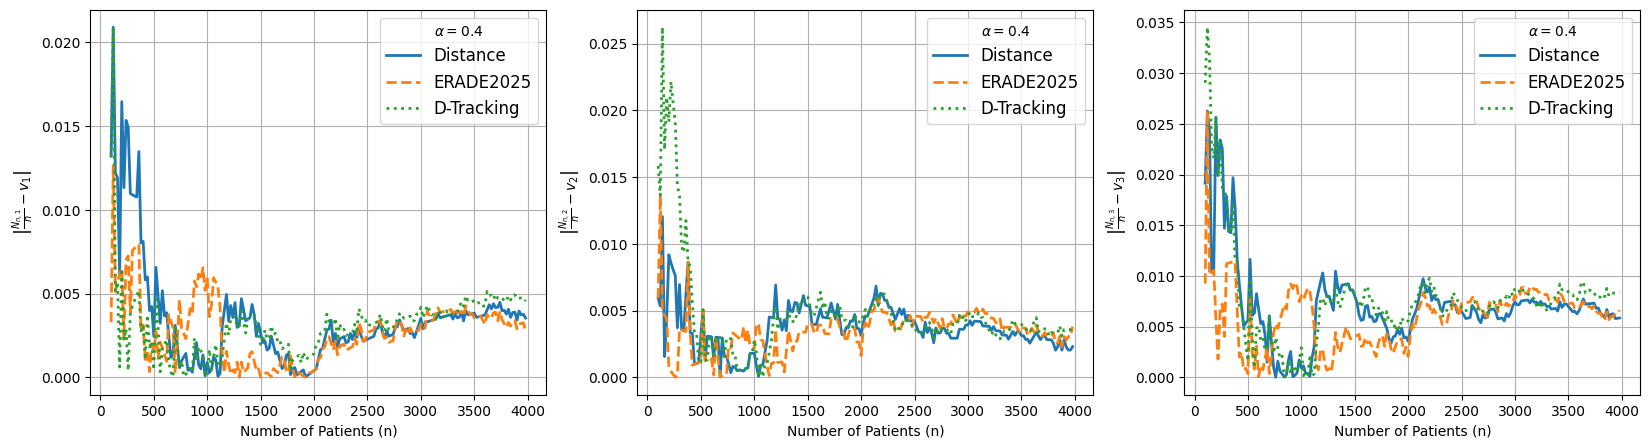

Check output in plots/fixed_target/rho_diff_0.pdf
Check output in plots/fixed_target/rho_diff_1.pdf
Check output in plots/fixed_target/rho_diff_2.pdf


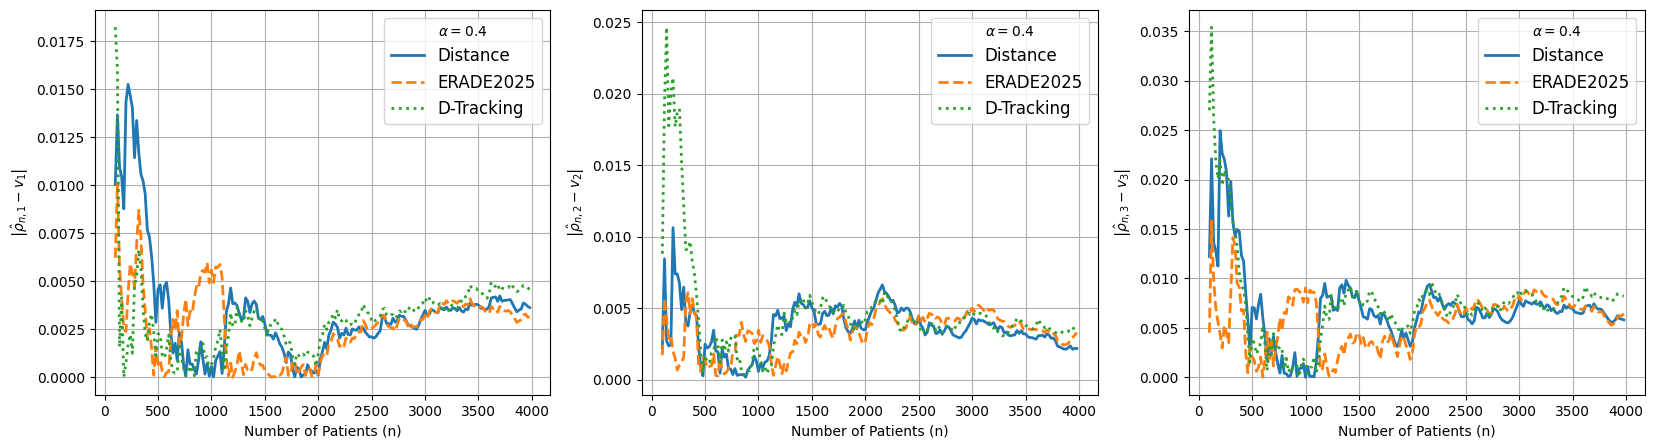

In [4]:
outputs_list=["prop_diff", "rho_diff"]
start_idx_lst = [100, 100, 20, 20]
traj_man.generate_plots(var_name, d_data, n_simulations, alpha, outputs_list=outputs_list, path_name = latex_plot_path + "fixed_target", start_idx_lst=start_idx_lst, line_width = 2, p_step=20, f_s=12, save_fig=True)


## 1.2. Scaled Allocation proportions and plug-in differences

Check output in plots/fixed_target/prop_diff_scaled_0.pdf
Check output in plots/fixed_target/prop_diff_scaled_1.pdf
Check output in plots/fixed_target/prop_diff_scaled_2.pdf


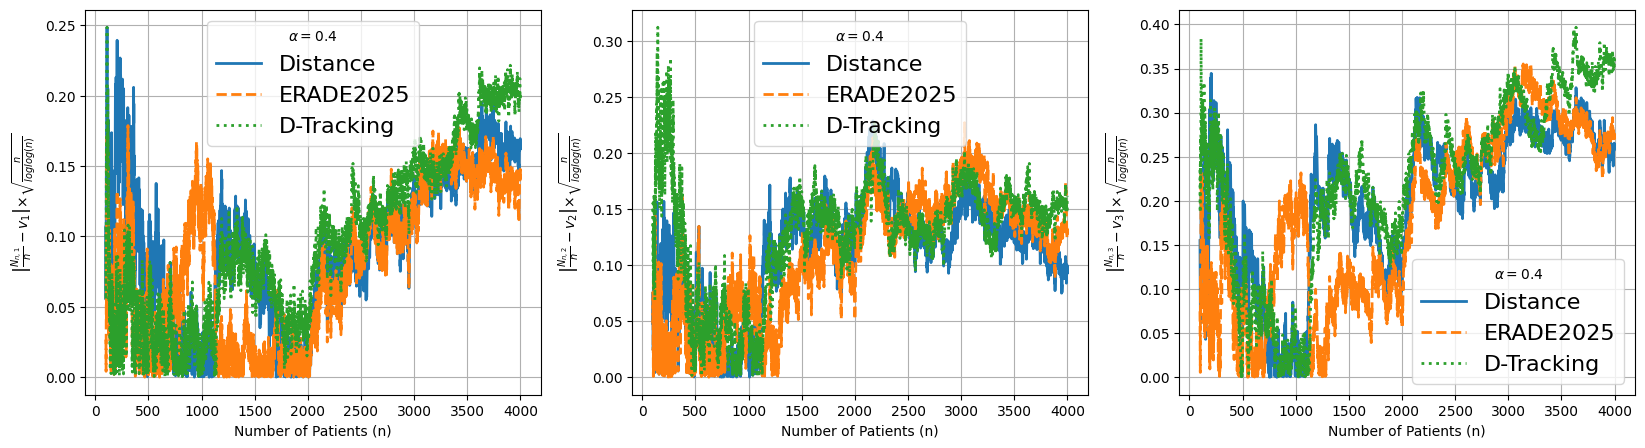

Check output in plots/fixed_target/rho_diff_scaled_0.pdf
Check output in plots/fixed_target/rho_diff_scaled_1.pdf
Check output in plots/fixed_target/rho_diff_scaled_2.pdf


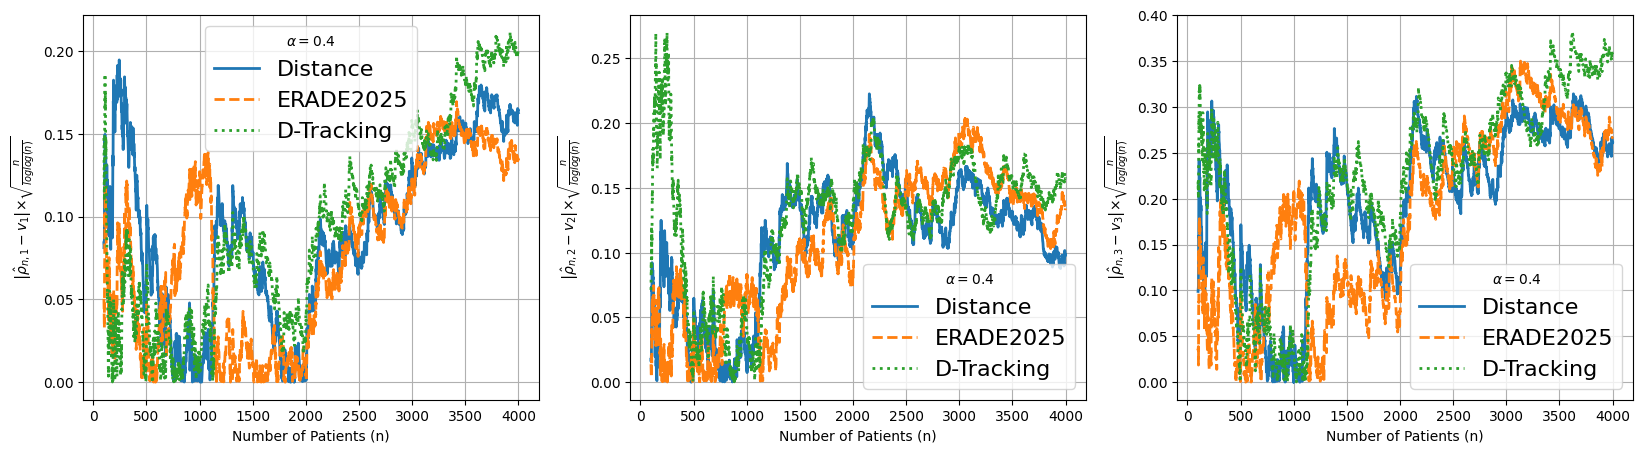

Check output in plots/fixed_target/prop_rho_diff_scaled_0.pdf
Check output in plots/fixed_target/prop_rho_diff_scaled_1.pdf
Check output in plots/fixed_target/prop_rho_diff_scaled_2.pdf


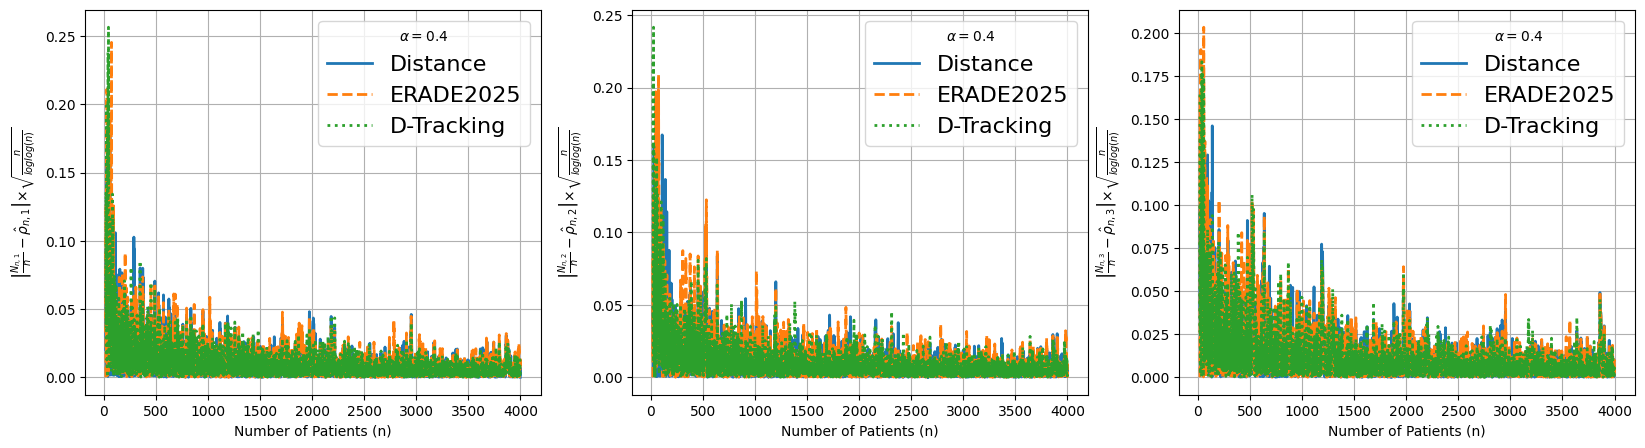

In [5]:
outputs_list=["prop_diff_scaled", "rho_diff_scaled", "prop_rho_diff_scaled"]
traj_man.generate_plots(var_name, d_data, n_simulations, alpha, path_name = latex_plot_path + "fixed_target", outputs_list=outputs_list, start_idx_lst=start_idx_lst, line_width = 2, save_fig=True)

## 2. Sparse Targets

In [6]:
n_patients = 1000
n_simulations = 500
true_probs_sparse = [np.array([0.1, 0.3, 0.6]), 
                  np.array([0.3, 0.4, 0.7]), 
                  np.array([0.4, 0.6, 0.8])]
d_data = {"true_probs_arr": true_probs_sparse, 
          "alloc_name_list": ["Tymofyeyev"], 
          "forced_exp_list": [False, True],
          "forced_exp_names": ["type-1"],  
          "version_list": ["Distance", "ERADE2025", "D-Tracking"], 
          "burn_in_list": [1]}
table_manager = TableManager(d_data)
power_res = table_manager.generate_table(alpha, n_patients, n_simulations, 0, record_power=False, use_parallel=True)

  0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
write_table_sparse(power_res, d_data, true_probs_sparse, [], n_simulations, n_patients)

Check output in tables/simulations_fe_sparse.tex


In [8]:
var_dict = {"alloc_name": ["Tymofyeyev"], 
            "version": ["Distance"], 
            "burn_in": [0], 
            "forced_exp": [False, True], 
            "forced_exp_names": ["type-1"],
            "alpha": [alpha]}
var_name = get_var_mult_entries(var_dict)

n_simulations = 500
n_patients = 2000
true_probs = np.array([0.4, 0.6, 0.8])

traj_man = TrajectoryManager(var_dict, true_probs)
d_data = traj_man.generate_trajectory_data(n_patients, n_simulations)

Check output in plots/sparse_target/prop_diff_0.pdf
Check output in plots/sparse_target/prop_diff_1.pdf
Check output in plots/sparse_target/prop_diff_2.pdf


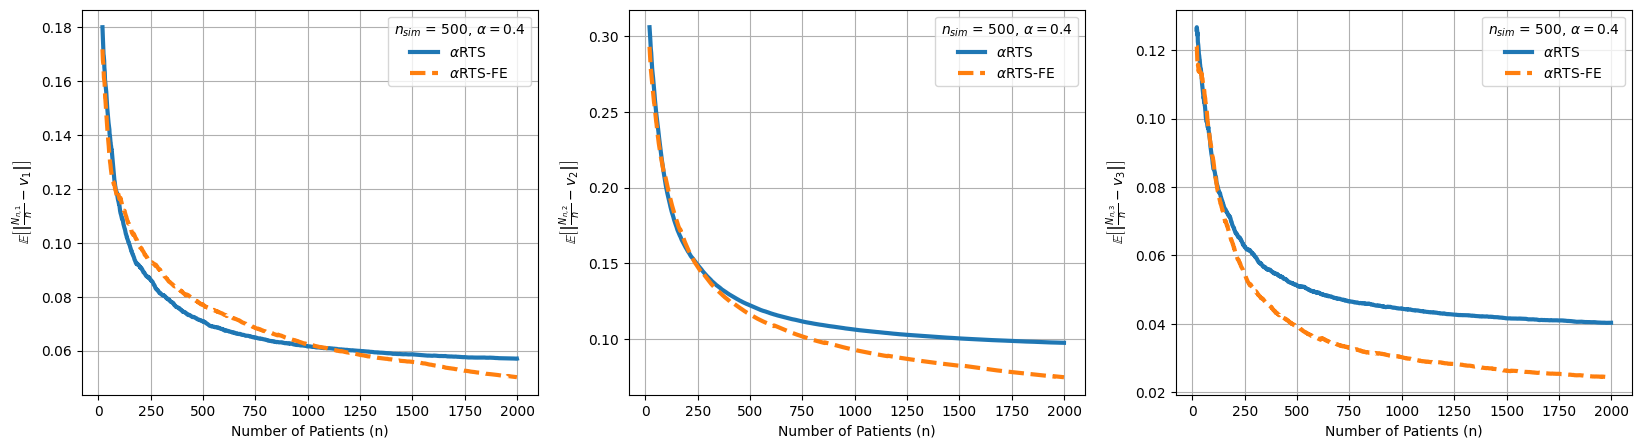

Check output in plots/sparse_target/rho_diff_0.pdf
Check output in plots/sparse_target/rho_diff_1.pdf
Check output in plots/sparse_target/rho_diff_2.pdf


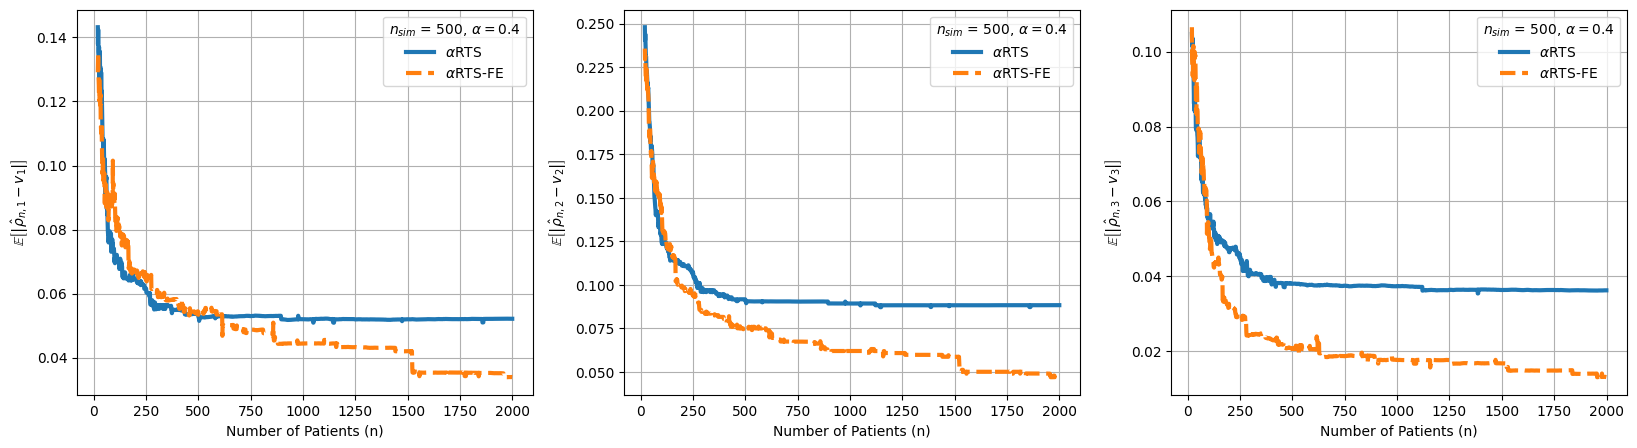

In [9]:
outputs_list=["prop_diff", "rho_diff"]
start_idx_lst = [20, 20, 20, 20]
traj_man.generate_plots(var_name, d_data, n_simulations, alpha, outputs_list=outputs_list, path_name = latex_plot_path + "sparse_target", start_idx_lst=start_idx_lst, f_s=14, save_fig=True)

# 3. Hypothesis testing

In [10]:
true_probs_null = [np.array([i/10, i/10, i/10, i/10]) for i in [1, 3, 5, 7, 9]]
true_probs_alt = [np.array([0.9, 0.8, 0.7, 0.6]), 
                  np.array([0.8, 0.7, 0.5, 0.4]), 
                  np.array([0.7, 0.6, 0.4, 0.2]), 
                  np.array([0.5, 0.4, 0.3, 0.2]),
                  np.array([0.4, 0.3, 0.2, 0.1])]

true_probs_arr = true_probs_null + true_probs_alt
K = len(true_probs_arr[0])

## 3.1 Fixed Target Allocation

In [11]:
n_simulations = 1000
n_patients = int(200)
d_data = {"true_probs_arr": true_probs_arr,         
          "alloc_name_list": ["Neyman"], 
          "forced_exp_list": [False, True],
          "forced_exp_names": ["type-1"],
          "version_list": ["Uniform", "Distance", "ERADE2025", "D-Tracking"], 
          "burn_in_list": [1]}
table_manager = TableManager(d_data)
power_res = table_manager.generate_table(alpha, n_patients, n_simulations, 0, record_power=False, use_parallel=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [12]:
write_table(power_res, d_data, true_probs_arr, true_probs_null, n_simulations, n_patients, setting_type = "fixed_target")

Check output in tables/simulations_fixed_target.tex


### Hard Instances

In [13]:
n_simulations = 1000
n_patients = int(200)
true_probs_difficile = [np.array([0.5, 0.5, 0.5, 0.55]), 
                        np.array([0.5, 0.5, 0.55, 0.55]), 
                        np.array([0.5, 0.55, 0.55, 0.55]), 
                        np.array([0.5, 0.5, 0.55, 0.6]), 
                        np.array([0.5, 0.55, 0.55, 0.6])] 

d_data = {"true_probs_arr": true_probs_difficile,         
          "alloc_name_list": ["Neyman"], 
          "forced_exp_list": [False, True],
          "forced_exp_names": ["type-1"],
          "version_list": ["Uniform", "Distance","ERADE2025", "D-Tracking"], 
          "burn_in_list": [1]}
table_manager = TableManager(d_data)
power_res = table_manager.generate_table(alpha, n_patients, n_simulations, 0, record_power=False, use_parallel=True)

  0%|          | 0/5 [00:00<?, ?it/s]

In [14]:
write_table(power_res, d_data, true_probs_difficile, [], n_simulations, n_patients, setting_type = "fixed_target_diff")

Check output in tables/simulations_fixed_target_diff.tex


### Power profile

In [15]:
var_dict = {"alloc_name": ["Neyman"], 
            "version": ["Uniform", "Distance", "ERADE2025", "D-Tracking"], 
            "burn_in": [1], 
            "forced_exp": [False],
            "forced_exp_names": ["BAI"],
            "alpha": [alpha]}
var_name = get_var_mult_entries(var_dict)

n_simulations = 1000
n_patients = 1500
true_probs = np.array([0.6, 0.65, 0.7, 0.75])

traj_man = TrajectoryManager(var_dict, true_probs)
d_data = traj_man.generate_trajectory_data(n_patients, n_simulations, use_parallel=True)

Check output in plots/fixed_target/power.pdf


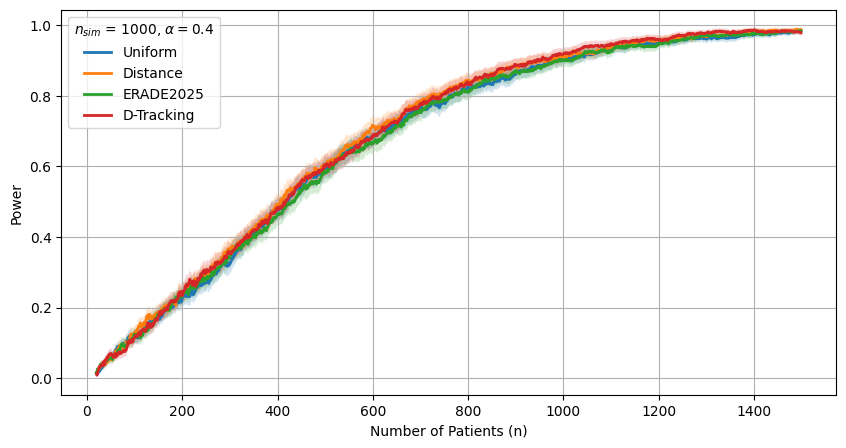

In [16]:
start_idx_lst = [20]
traj_man.generate_plots(var_name, d_data, n_simulations, alpha, path_name = latex_plot_path + "fixed_target", outputs_list=["power"], start_idx_lst=start_idx_lst, line_width = 2, change_line_style=False, save_fig=True)

## 3.2 Fixed Targeting 

In [17]:
n_simulations = 1000
n_patients = int(200)
d_data = {"true_probs_arr": true_probs_arr, 
          "alloc_name_list": ["Tymofyeyev", "Neyman", "RSIHR"],         
          "forced_exp_list": [False, True], 
          "forced_exp_names": ["type-1"],
          "version_list": ["Distance"], 
          "burn_in_list": [1]}
table_manager = TableManager(d_data)
power_res = table_manager.generate_table(alpha, n_patients, n_simulations, 0, record_power=True, use_parallel=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [18]:
write_table(power_res, d_data, true_probs_arr, true_probs_null, n_simulations, n_patients, setting_type = "fixed_targeting")

Check output in tables/simulations_fixed_targeting.tex


### Hard Instances

In [19]:
n_simulations = 1000
n_patients = int(200)
true_probs_difficile = [np.array([0.5, 0.5, 0.5, 0.55]), 
                        np.array([0.5, 0.5, 0.55, 0.55]), 
                        np.array([0.5, 0.55, 0.55, 0.55]), 
                        np.array([0.5, 0.5, 0.55, 0.6]), 
                        np.array([0.5, 0.55, 0.55, 0.6])] 

d_data = {"true_probs_arr": true_probs_difficile,    
          "alloc_name_list": ["Tymofyeyev", "Neyman", "RSIHR"], 
        #   "alloc_name_list": ["Neyman"], 
          "forced_exp_list": [False, True], 
          "forced_exp_names": ["type-1"],
          "version_list": ["Distance"], 
          "burn_in_list": [1]}
table_manager = TableManager(d_data)
power_res = table_manager.generate_table(alpha, n_patients, n_simulations, 0, record_power=True, use_parallel=True)

  0%|          | 0/5 [00:00<?, ?it/s]

In [20]:
write_table(power_res, d_data, true_probs_difficile, [], n_simulations, n_patients, setting_type = "fixed_targeting_diff")

Check output in tables/simulations_fixed_targeting_diff.tex


### Power profile

In [21]:
var_dict = {"alloc_duo": ["Neyman-Uniform", "Tymofyeyev-Distance", "Neyman-Distance", "RSIHR-Distance"],             
            "burn_in": [1], 
            "forced_exp": [True],
            "forced_exp_names": ["type-1"],
            "alpha": [alpha]}
var_name = get_var_mult_entries(var_dict)

n_simulations = 1000
n_patients = 1500
true_probs = np.array([0.6, 0.65, 0.7, 0.75])

traj_man = TrajectoryManager(var_dict, true_probs)
d_data = traj_man.generate_trajectory_data_2(n_patients, n_simulations)

Check output in plots/fixed_targeting/power.pdf


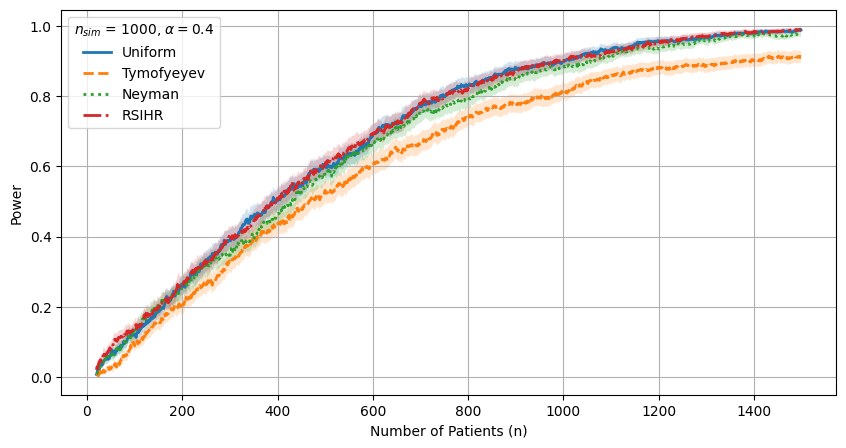

In [22]:
start_idx_lst = [20]
traj_man.generate_plots(var_name, d_data, n_simulations, alpha, path_name = latex_plot_path + "fixed_targeting", outputs_list=["power"], start_idx_lst=start_idx_lst, line_width = 2, save_fig=True)